##Task
Using the dataset in EFIplus_medit.zip:
1. Check visually if any of the continuous environmental variables in the EFIplus_medit dataset (Altitude,
Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul) would
require a data transformation in order to apply parametric tests.
2. Apply the appropriate data transformation and check the new distributions.
3. Create a column with the total number of species present (the species richness) in each sampling site
(NOTE: the first species in the dataset is ‘Abramis brama’ and all the columns to the right correspond to
species presence/absence).
4. Check the existence of bivariate outliers in the relationship between Mean Annual Temperature
(‘temp_ann’) and species richness using an appropriate plot. Run a bivariate isolation forest to detect
outliers and plot the result.
5. Explore visually, using a single plot, if this relationship (temp_ann x species richness) may vary across
countries.

#### Load and view data

In [ ]:
!pip install scikit_posthocs

import pandas as pd
import plotly.express as px
import numpy as np
import zipfile
import seaborn as sns # For plotting
import matplotlib.pyplot as plt # For showing plots
import scipy.stats as sts
import scikit_posthocs as sp
import statsmodels.stats as stm
from statsmodels.graphics.gofplots import qqplot

In [ ]:
df = pd.read_csv('https://github.com/isa-ulisboa/greends-avcad-2026/raw/f19803d655184db021901ad1e257132cf0c1cab8/examples/EFIplus_medit.zip', compression='zip', sep=';')

In [ ]:
df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(38), int64(120), object(6)
memory usage: 6.3+ MB


In [ ]:
df.describe()

,Latitude,Longitude,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,Calib_morphol,Calib_wqual,Geomorph1,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
count,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,4.615000e+03,...,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000,5011.000000
mean,41.660286,-4.220392,0.288964,0.790860,0.278388,0.811814,0.403313,0.460387,0.497306,4.550399e-12,...,0.000399,0.085412,0.000599,0.000399,0.012373,0.000200,0.196568,0.068250,0.132708,0.031132
std,1.654641,4.754419,0.453327,0.406735,0.448250,0.390900,0.490611,0.498478,0.500043,1.000108e+00,...,0.019976,0.279522,0.024463,0.019976,0.110554,0.014127,0.397442,0.252199,0.339293,0.173690
min,36.213984,-9.459453,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.465112e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.450919,-7.716600,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.129179e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,42.316060,-6.176062,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,4.515341e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,42.904789,-1.959129,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.319150e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,45.098423,15.625773,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.345204e-01,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.columns.tolist()

['Site_code',
 'Latitude',
 'Longitude',
 'Country',
 'Catchment_name',
 'Galiza',
 'Subsample',
 'Calib_EFI_Medit',
 'Calib_connect',
 'Calib_hydrol',
 'Calib_morphol',
 'Calib_wqual',
 'Geomorph1',
 'Geomorph2',
 'Geomorph3',
 'Water_source_type',
 'Flow_regime',
 'Altitude',
 'Geological_typology',
 'Actual_river_slope',
 'Natural_sediment',
 'Elevation_mean_catch',
 'prec_ann_catch',
 'temp_ann',
 'temp_jan',
 'temp_jul',
 'Barriers_catchment_down',
 'Barriers_river_segment_up',
 'Barriers_river_segment_down',
 'Barriers_number_river_segment_up',
 'Barriers_number_river_segment_down',
 'Barriers_distance_river_segment_up',
 'Barriers_distance_river_segment_down',
 'Impoundment',
 'Hydropeaking',
 'Water_abstraction',
 'Hydro_mod',
 'Temperature_impact',
 'Velocity_increase',
 'Reservoir_flushing',
 'Sedimentation',
 'Channelisation',
 'Cross_sec',
 'Instream_habitat',
 'Riparian_vegetation',
 'Embankment',
 'Floodprotection',
 'Floodplain',
 'Toxic_substances',
 'Acidification',
 '

#### Check for Normality
visually if any of the continuous environmental variables in the EFIplus_medit dataset (Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul) would require a data transformation in order to apply parametric tests.

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np
from scipy import stats

In [ ]:
#plotly subplot method, px.histogram(df, x="Altitude") for 1, hover for sample info

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np
from scipy import stats

variables = ['Altitude', 'Actual_river_slope', 'Elevation_mean_catch',
             'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul']

# Same colours as your matplotlib plot
colors = ['#6264E0', '#E05C2A', '#2ECC8E', '#9B59B6', '#E8A838', '#2BC4D8', '#E8547A']

fig = make_subplots(rows=7, cols=3,
                    column_titles=['Histogram', 'Boxplot', 'Q-Q Plot'],
                    row_titles=variables,
                    horizontal_spacing=0.08,
                    vertical_spacing=0.04)

for i, (var, color) in enumerate(zip(variables, colors)):
    data = df[var].dropna()
    row = i + 1

    # --- Histogram ---
    fig.add_trace(go.Histogram(x=data, name=var, showlegend=False,
                               marker_color=color), row=row, col=1)

    # --- Boxplot ---
    fig.add_trace(go.Box(x=data, name=" ", showlegend=False,
                         marker_color=color, line_color=color), row=row, col=2)

    # --- Q-Q Plot ---
    (osm, osr), (slope, intercept, r) = stats.probplot(data)
    fig.add_trace(go.Scatter(x=osm, y=osr, mode='markers', name=var,
                             marker=dict(size=3, color=color), showlegend=False), row=row, col=3)
    line_x = [min(osm), max(osm)]
    line_y = [slope * x + intercept for x in line_x]
    fig.add_trace(go.Scatter(x=line_x, y=line_y, mode='lines',
                             line=dict(color='red', width=1.5), showlegend=False), row=row, col=3)

fig.update_layout(height=200 * 7, width=900,
                  title_text="Histograms, Boxplots & Q-Q Plots of Environmental Variables")
fig.show()

| Variable | Normality Met | Transformation Strategy |
|----------|--------------|------------------------|
| Altitude |  No — right skew | log(x + 1) |
| Actual_river_slope |  No — severe right skew | log(x + 1) |
| Elevation_mean_catch |  No — right skew | log(x + 1) |
| prec_ann_catch |  No — multimodal | sqrt(x) |
| temp_ann | Borderline — left skew | reflect + log, or none |
| temp_jan | Yes | None |
| temp_jul | Yes | None |

##### so from this — altitude, slope, elevation and precip all need transforming, temp variables look fine. multimodal pattern in prec_ann_catch is a bit sus but that's probably just the data structure

#### Transorm and check distributions

In [ ]:
df['cbrt_Altitude'] = np.cbrt(df['Altitude'])
df['log1_Actual_river_slope'] = np.log1p(df['Actual_river_slope'])
df['sqrt_Elevation_mean_catch'] = np.sqrt(df['Elevation_mean_catch'])
df['sqrt_prec_ann_catch'] = np.sqrt(df['prec_ann_catch'])
df['sqrt_reflect_temp_ann'] = np.sqrt((df['temp_ann'].max() + 1) - df['temp_ann'])

transformed_variables = [
    'cbrt_Altitude', 'log1_Actual_river_slope', 'sqrt_Elevation_mean_catch',
    'sqrt_prec_ann_catch', 'sqrt_reflect_temp_ann', 'temp_jan', 'temp_jul'
]

##### River slope not responding well to log or cube transormations, checking for null values

In [ ]:
# Check for nulls and zeros
print("Null values:", df['Actual_river_slope'].isna().sum())
print("Zero values:", (df['Actual_river_slope'] == 0).sum())
print("Values < 0:", (df['Actual_river_slope'] < 0).sum())

# See the distribution of low values more closely
print("\nValue counts for 0s and near-0s:")
print(df['Actual_river_slope'].describe())

Null values: 36
Zero values: 10
Values < 0: 0

Value counts for 0s and near-0s:
count    4975.000000
mean       14.582432
std        22.596125
min         0.000000
25%         3.509500
50%         8.000000
75%        17.170000
max       774.000000
Name: Actual_river_slope, dtype: float64


In [ ]:
# See how many values are extreme outliers
print((df['Actual_river_slope'] > 100).sum())
print((df['Actual_river_slope'] > 200).sum())
print((df['Actual_river_slope'] > 500).sum())

# Look at the top 10 values
print(df['Actual_river_slope'].nlargest(10))

48
3
1
1566    774.000
3567    306.088
4084    225.306
924     193.689
4681    173.400
3035    169.933
3043    169.933
3044    169.933
4150    164.400
3280    162.001
Name: Actual_river_slope, dtype: float64


In [ ]:
# Investigate the duplicate values
print(df.loc[[3035, 3043, 3044], ['Site_code', 'Actual_river_slope', 'Latitude', 'Longitude']])

       Site_code  Actual_river_slope   Latitude  Longitude
3035  ES_37_0001             169.933  42.747244   1.100833
3043  ES_37_0009             169.933  42.746966   1.101111
3044  ES_37_0010             169.933  42.749466   1.100000


In [ ]:
# Check what the 99th percentile is
print(df['Actual_river_slope'].quantile(0.99))  # likely around 100

# Cap and transform
threshold = df['Actual_river_slope'].quantile(0.99)
df['log_slope_capped'] = np.log1p(df['Actual_river_slope'].clip(upper=threshold))

# Update transformed variables list
transformed_variables = [
    'cbrt_Altitude',
    'log_slope_capped',           # 👈 updated
    'sqrt_Elevation_mean_catch',
    'sqrt_prec_ann_catch',
    'sqrt_reflect_temp_ann',
    'temp_jan',
    'temp_jul'
]

98.79838000000018


##### Visual Normality Check After Transormations

| Variable | Transformation | Status |
|----------|---------------|--------|
| Altitude | `cbrt` | Good |
| Actual_river_slope | `log1p + 99th percentile cap` | Best achievable — 10 true zeros remain |
| Elevation_mean_catch | `sqrt` | Good |
| prec_ann_catch | `sqrt` | Multimodal — structural issue |
| temp_ann | `sqrt + reflect` | Good |
| temp_jan | none | Good |
| temp_jul | none | Good |

##### transformations mostly worked — slope was the tricky one, had extreme outliers pushing the skew way up. capped at 99th percentile + log1p was the best we could get. prec_ann_catch is still multimodal which no transformation will fix, that's just how the data is distributed across regions

In [ ]:
fig = make_subplots(rows=7, cols=3,
                    column_titles=['Histogram', 'Boxplot', 'Q-Q Plot'],
                    horizontal_spacing=0.10,
                    vertical_spacing=0.03)

for i, (var, color) in enumerate(zip(transformed_variables, colors)):
    data = df[var].dropna()
    row = i + 1

    fig.add_trace(go.Histogram(x=data, showlegend=False,
                               marker_color=color), row=row, col=1)
    fig.add_trace(go.Box(x=data, showlegend=False,
                         marker_color=color, line_color=color), row=row, col=2)
    (osm, osr), (slope, intercept, r) = stats.probplot(data)
    fig.add_trace(go.Scatter(x=osm, y=osr, mode='markers',
                             marker=dict(size=3, color=color), showlegend=False), row=row, col=3)
    line_x = [min(osm), max(osm)]
    line_y = [slope * x + intercept for x in line_x]
    fig.add_trace(go.Scatter(x=line_x, y=line_y, mode='lines',
                             line=dict(color='red', width=1.5), showlegend=False), row=row, col=3)

    # Add horizontal row label to the left of each row
    fig.add_annotation(
        text=var,
        x=-0.02,
        y=(1 - (i + 0.5) / 7),
        xref='paper', yref='paper',
        showarrow=False,
        textangle=0,          # horizontal text ✅
        font=dict(size=9),
        xanchor='right'
    )

fig.update_layout(
    height=200 * 7, width=800,
    title_text="Transformed Variables — Histograms, Boxplots & Q-Q Plots",
    margin=dict(l=150)        # extra left margin so labels aren't clipped
)
fig.show()

#### Create a column with total number of species preset
species richness per sample site, had to be careful to only grab species and not the appended transformed columns

In [ ]:
# Slice from first to last species only
first_species_idx = df.columns.get_loc('Abramis brama')
last_species_idx = df.columns.get_loc('Iberochondrostoma_sp') + 1  # +1 to include it

df['species_richness'] = df.iloc[:, first_species_idx:last_species_idx].sum(axis=1)

print(df['species_richness'].describe())
print(df[['Site_code', 'species_richness']].head(10))

count    5011.000000
mean        3.508481
std         2.879080
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        29.000000
Name: species_richness, dtype: float64
    Site_code  species_richness
0  ES_01_0002                 1
1  ES_02_0001                 1
2  ES_02_0002                 1
3  ES_02_0003                 2
4  ES_02_0004                 2
5  ES_02_0005                 4
6  ES_02_0006                 4
7  ES_02_0007                 6
8  ES_02_0008                 4
9  ES_02_0010                 1


In [ ]:
print((df['species_richness'] % 1 == 0).all())

True


##### species richness added — double checked it's only summing the actual species columns and not picking up any of the transformed ones we added earlier. all integers which is what we'd expect from presence/absence data

####Check the existence of bivariate outliers in the relationship between Mean Annual Temperature (‘temp_ann’) and species richness using an appropriate plot. Run a bivariate isolation forest to detect outliers and plot the result.

In [ ]:
from sklearn.ensemble import IsolationForest

# Step 1 — prepare data
X = df[['temp_ann', 'species_richness']].dropna()

# Step 2 — fit isolation forest
iso = IsolationForest(contamination=0.05, random_state=42)
X['outlier'] = iso.fit_predict(X)
X['outlier_label'] = X['outlier'].map({1: 'Inlier', -1: 'Outlier'})  # 👈 readable labels

# Step 3 — plot
import plotly.express as px
fig = px.scatter(X, x='temp_ann', y='species_richness',
                 color='outlier_label',
                 color_discrete_map={'Inlier': '#636EFA', 'Outlier': 'red'},  # 👈 outliers in red
                 labels={'temp_ann': 'Mean Annual Temperature',
                         'species_richness': 'Species Richness'},
                 title='Bivariate Outlier Detection — temp_ann vs Species Richness')
fig.show()

print(f"Number of outliers detected: {(X['outlier'] == -1).sum()}")
print(f"Percentage flagged: {(X['outlier'] == -1).mean()*100:.1f}%")

Number of outliers detected: 237
Percentage flagged: 4.9%


##### isolation forest flagged ~5% as outliers — these are mostly sites with really high species richness for their temperature, or just weird combos that don't fit the general pattern. makes sense visually too, you can see some points sitting far from the main cloud

####Explore visually, using a single plot, if this relationship (temp_ann x species richness) may vary across countries.

In [ ]:
fig = px.scatter(df, x='temp_ann', y='species_richness', color='Country',
                 color_discrete_map={
                    'Spain': '#E05C2A',      # strong orange
                    'France': '#283593',     # steel blue
                    'Italy': '#2ECC71',      # bright green
                    'Portugal': '#F1C40F'    # yellow
                 },
                 labels={'temp_ann': 'Mean Annual Temperature',
                         'species_richness': 'Species Richness'},
                 title='Temperature vs Species Richness by Country')

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgrey', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='lightgrey', zeroline=False),
)

fig.update_traces(marker=dict(size=6, opacity=0.7))

fig.show()

In [ ]:
# Filter to inliers only
aligned_outliers = (X['outlier'] == 1).reindex(df.index, fill_value=False)
df_clean = df[aligned_outliers].copy() # X is the dataframe from the isolation forest step

fig = px.scatter(df_clean, x='temp_ann', y='species_richness', color='Country',
                 color_discrete_map={
                     'Spain': '#E74C3C',
                     'France': '#1B3F8B',
                     'Italy': '#27AE60',
                     'Portugal': '#F39C12'
                 },
                 trendline='ols',
                 trendline_scope='trace',
                 opacity=0.5,
                 labels={'temp_ann': 'Mean Annual Temperature',
                         'species_richness': 'Species Richness'},
                 title='Temperature vs Species Richness by Country (outliers removed)')

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgrey', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='lightgrey', zeroline=False),
)

# Make trendlines thicker and points smaller so lines stand out
fig.update_traces(marker=dict(size=4), selector=dict(mode='markers'))
fig.update_traces(line=dict(width=3), selector=dict(mode='lines'))

fig.show()

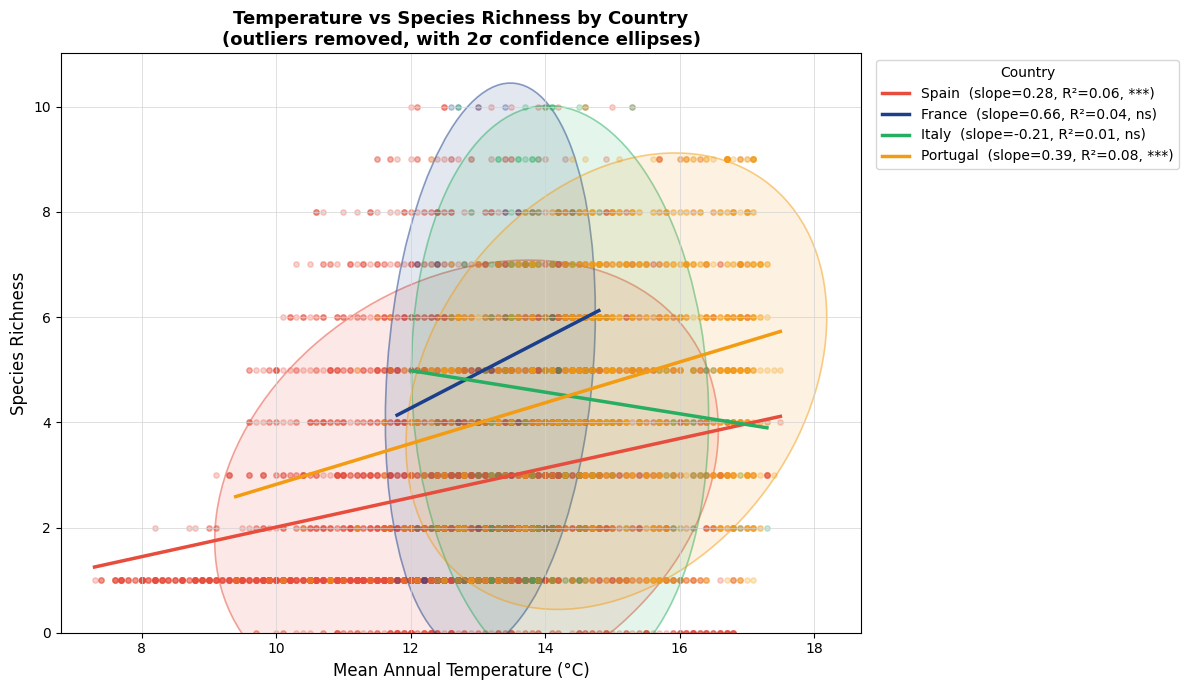

In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

country_colors = {
    'Spain':    '#E74C3C',
    'France':   '#1B3F8B',
    'Italy':    '#27AE60',
    'Portugal': '#F39C12'
}

fig, ax = plt.subplots(figsize=(12, 7))

for country, color in country_colors.items():
    subset = df_clean[df_clean['Country'] == country][['temp_ann', 'species_richness']].dropna()
    if len(subset) < 3:
        continue
    x = subset['temp_ann'].values
    y = subset['species_richness'].values

    # Scatter points
    ax.scatter(x, y, color=color, alpha=0.25, s=15)

    # Confidence ellipse
    confidence_ellipse(x, y, ax, n_std=2.0, facecolor=color, alpha=0.12, edgecolor='none')
    confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', edgecolor=color, alpha=0.5, linewidth=1.2)

    # Trendline
    m, b, r, p, se = sts.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.plot(x_line, y_line, color=color, linewidth=2.5,
            label=f'{country}  (slope={m:.2f}, R²={r**2:.2f}, {sig})')

ax.set_xlabel('Mean Annual Temperature (°C)', fontsize=12)
ax.set_ylabel('Species Richness', fontsize=12)
ax.set_title('Temperature vs Species Richness by Country\n(outliers removed, with 2σ confidence ellipses)', fontsize=13, fontweight='bold')
ax.legend(title='Country', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_facecolor('white')
ax.grid(True, color='lightgrey', linewidth=0.5)
ax.set_ylim(bottom=0)
ax.set_xlim(left=df_clean['temp_ann'].min() - 0.5)
plt.tight_layout()
plt.show()

##### the relationship definitely varies by country italy, portugal and spain all show a negative trend (warmer = fewer species) which makes sense for cold-water fish. france is basically flat which is interesting, could be fewer sites or just different assemblages. spain has the widest temperature range which is probably why the trend is clearest there